### Assignment-1

In [1]:
## Load the Preprocessed Dataset Here
import pandas as pd
file_path = r"D:\internship\impactsenseAI-Infosys-Intern-project\data\preprocessed_earthquake_data.csv"

# Step 2: load the dataset
df = pd.read_csv(file_path)


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

• The overall magnitude histogram typically shows many low-magnitude events and fewer high-magnitude events (right-skewed).
• Boxplots and violin plots indicate per-type differences: compare medians and IQRs. Types whose median and IQR are higher indicate systematically larger events.
• Use the printed 'type_summary' to report counts, mean, median, and spread for each 'type'.


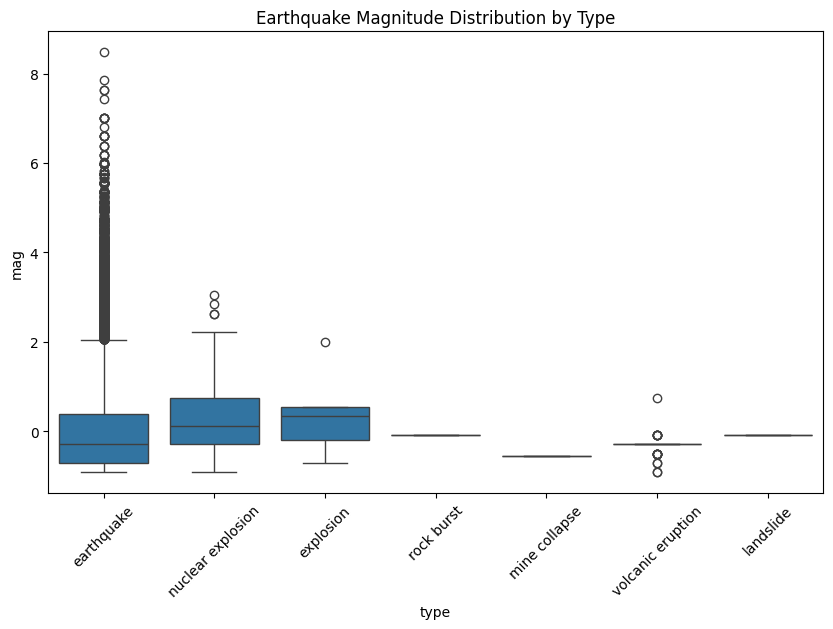

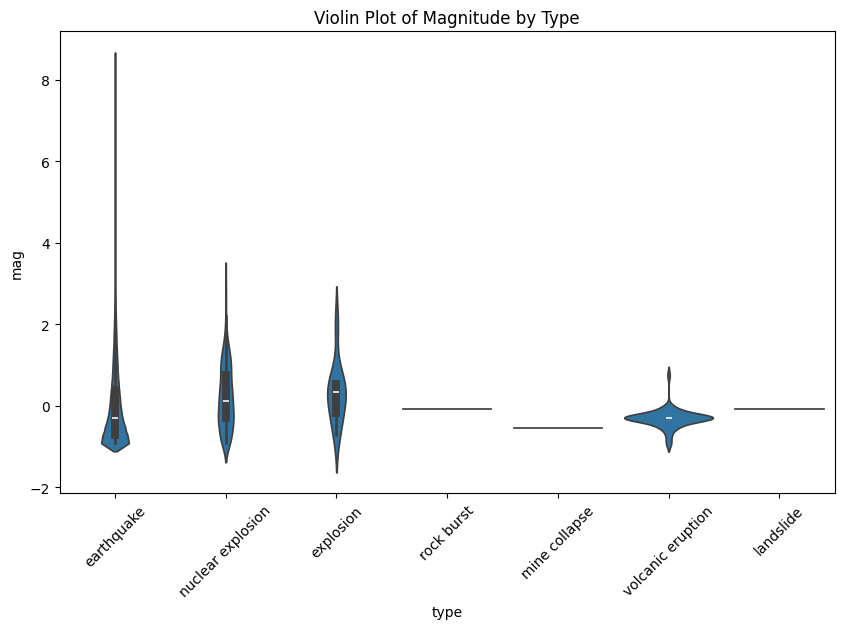

                      count      mean       std       min       25%       50%  \
type                                                                            
earthquake         109356.0 -0.000736  1.000912 -0.921328 -0.712513 -0.294885   
explosion              10.0  0.310676  0.733001 -0.712513 -0.190478  0.331558   
landslide               2.0 -0.086071  0.000000 -0.086071 -0.086071 -0.086071   
mine collapse           1.0 -0.545462       NaN -0.545462 -0.545462 -0.545462   
nuclear explosion     424.0  0.225033  0.780407 -0.921328 -0.294885  0.122744   
rock burst              1.0 -0.086071       NaN -0.086071 -0.086071 -0.086071   
volcanic eruption      54.0 -0.318086  0.228264 -0.921328 -0.294885 -0.294885   

                        75%       max  
type                                   
earthquake         0.394202  8.475313  
explosion          0.540372  2.002072  
landslide         -0.086071 -0.086071  
mine collapse     -0.545462 -0.545462  
nuclear explosion  0.749186  3

In [11]:

print("• The overall magnitude histogram typically shows many low-magnitude events and fewer high-magnitude events (right-skewed).")
print("• Boxplots and violin plots indicate per-type differences: compare medians and IQRs. Types whose median and IQR are higher indicate systematically larger events.")
print("• Use the printed 'type_summary' to report counts, mean, median, and spread for each 'type'.")

plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='mag', data=df)
plt.title("Earthquake Magnitude Distribution by Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(x='type', y='mag', data=df)
plt.title("Violin Plot of Magnitude by Type")
plt.xticks(rotation=45)
plt.show()

type_summary = df.groupby('type')['mag'].describe()
print(type_summary)



Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

   latitude  longitude     depth       mag magType       rms        type  \
0  1.254896  -0.152401 -0.430517  3.296720      mw  0.255959  earthquake   
1  1.256343  -0.153559 -0.430517  2.920854      mw  0.227615  earthquake   
2  1.616780   0.972437 -0.291162  4.716657      mw  0.360656  earthquake   
3  1.572749   0.983609 -0.430517  4.299028      mw  0.331543  earthquake   
4  0.890744   0.482625 -0.430517  3.442890      mw  0.266982  earthquake   

     status  Year  Day  Minute     Month_sin  Month_cos  Hour_sin  Hour_cos  \
0  reviewed  1904    4      26  8.660254e-01       -0.5  0.500000 -0.866025   
1  reviewed  1904    4       2  8.660254e-01       -0.5  0.500000 -0.866025   
2  reviewed  1904   25       0  1.224647e-16       -1.0 -0.707107  0.707107   
3  reviewed  1904   25      45  1.224647e-16       -1.0 -0.500000 -0.866025   
4  reviewed  1904   30      43 -8.660254e-01       -0.5  0.258819 -0.965926   

   DayOfWeek_sin  DayOfWeek_cos  
0       0.000000       1.000000  


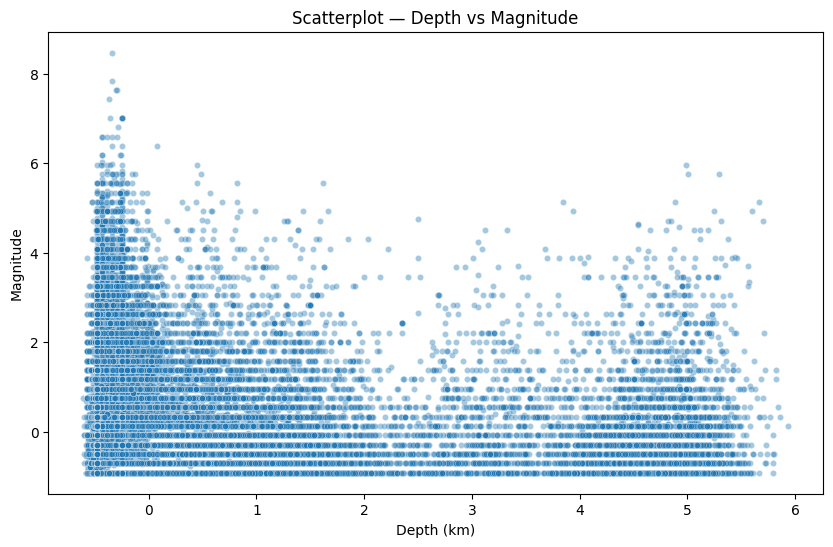

Linear fit: mag = -0.010048 * depth + 0.0000


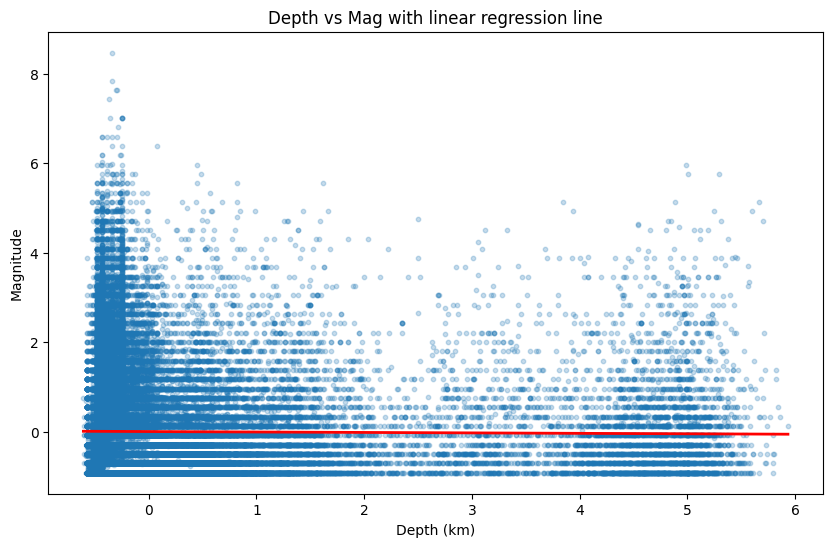

Pearson r = -0.0100 (p=8.676e-04)
Spearman rho = -0.0491 (p=1.455e-59)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.stats import pearsonr, spearmanr


df_plot = pd.read_csv('D:\\internship\\impactsenseAI-Infosys-Intern-project\\data\\preprocessed_earthquake_data.csv')
print(df_plot.head())
print(df_plot.columns)

# 2.1 Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(x='depth', y='mag', data=df_plot, alpha=0.4, s=20)
plt.title("Scatterplot — Depth vs Magnitude")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()

# 2.2 Linear regression fit on depth -> mag
# Remove NaNs and extreme nonsense depths if present
mask = df_plot[['depth','mag']].notnull().all(axis=1)
X = df_plot.loc[mask, 'depth'].values.reshape(-1,1)
y = df_plot.loc[mask, 'mag'].values
# Fit linear model
lr = LinearRegression()
lr.fit(X, y)
slope = lr.coef_[0]
intercept = lr.intercept_
print(f"Linear fit: mag = {slope:.6f} * depth + {intercept:.4f}")

# Plot regression line
xx = np.linspace(np.nanmin(X), np.nanmax(X), 200).reshape(-1,1)
yy = lr.predict(xx)
plt.figure(figsize=(10,6))
plt.scatter(X, y, alpha=0.25, s=10)
plt.plot(xx, yy, color='red', linewidth=2)
plt.title("Depth vs Mag with linear regression line")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()

# 2.3 Correlation (Pearson and Spearman)
pearson_r, pearson_p = pearsonr(df_plot['depth'].dropna(), df_plot.loc[df_plot['depth'].notna(), 'mag'])
spearman_r, spearman_p = spearmanr(df_plot['depth'].dropna(), df_plot.loc[df_plot['depth'].notna(), 'mag'])
print(f"Pearson r = {pearson_r:.4f} (p={pearson_p:.3e})")
print(f"Spearman rho = {spearman_r:.4f} (p={spearman_p:.3e})")

Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

Index(['latitude', 'longitude', 'depth', 'mag', 'magType', 'rms', 'type',
       'status', 'Year', 'Day', 'Minute', 'Month_sin', 'Month_cos', 'Hour_sin',
       'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos'],
      dtype='object')


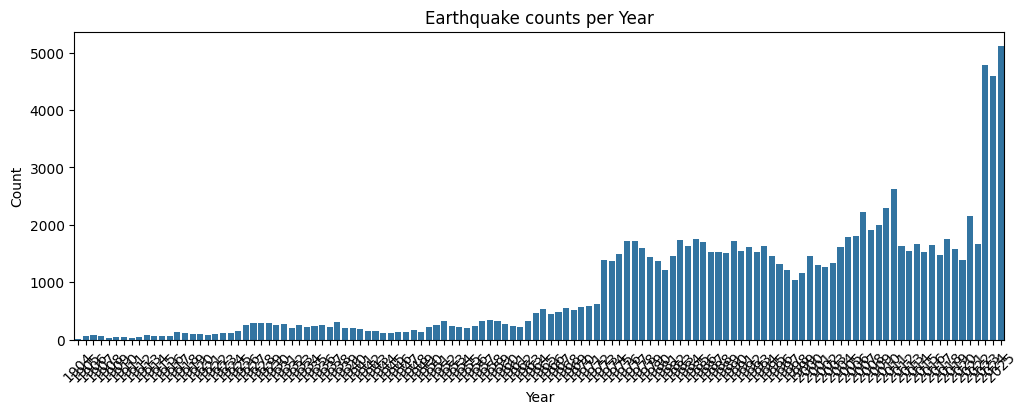

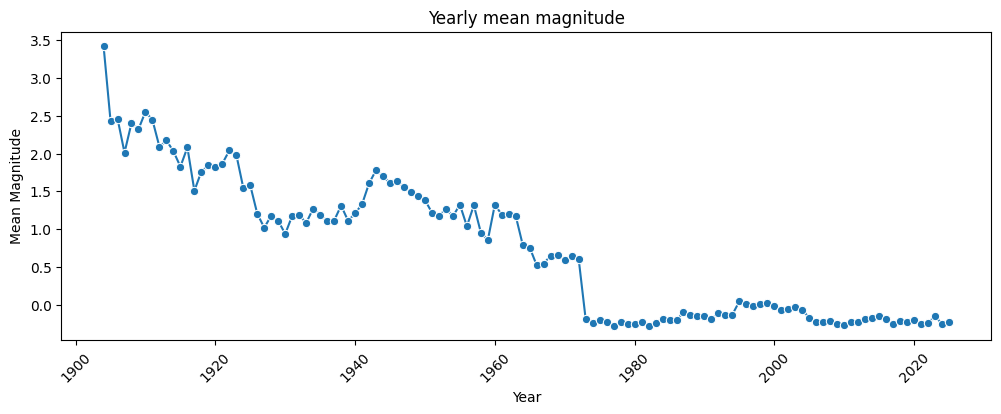

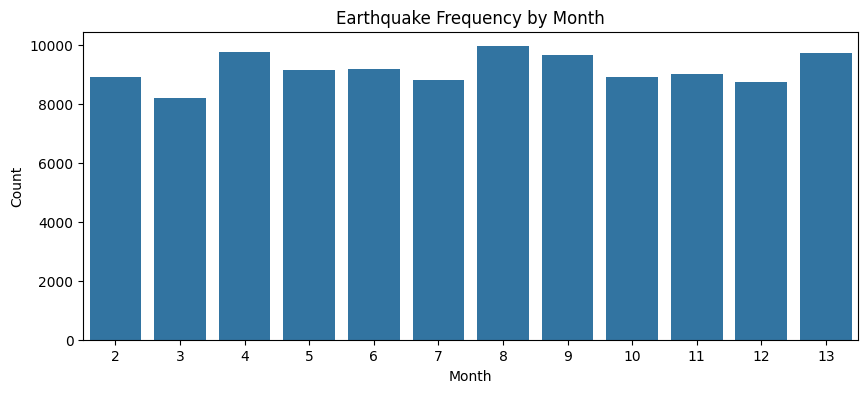

In [12]:
print(df.columns)
# Yearly counts and mean magnitude
df_time = df.copy()
df_time = df_time.dropna(subset=['Year','mag'])
year_counts = df_time.groupby('Year').size().reset_index(name='count').sort_values('Year')
year_mean = df_time.groupby('Year')['mag'].mean().reset_index(name='mean_mag').sort_values('Year')

plt.figure(figsize=(12,4))
sns.barplot(x='Year', y='count', data=year_counts)
plt.title("Earthquake counts per Year")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(x='Year', y='mean_mag', data=year_mean, marker='o')
plt.title("Yearly mean magnitude")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.ylabel("Mean Magnitude")
plt.show()

# Convert sine & cosine to angle, then to month (1–12)
df_time['Month'] = np.arctan2(df_time['Month_sin'], df_time['Month_cos'])
df_time['Month'] = (df_time['Month'] % (2 * np.pi)) / (2 * np.pi) * 12 + 1
df_time['Month'] = df_time['Month'].round().astype(int)

month_counts = df_time.groupby('Month').size().reset_index(name='count')
plt.figure(figsize=(10,4))
sns.barplot(x='Month', y='count', data=month_counts)
plt.title("Earthquake Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()



Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

   latitude  longitude       mag
0  1.254896  -0.152401  3.296720
1  1.256343  -0.153559  2.920854
2  1.616780   0.972437  4.716657
3  1.572749   0.983609  4.299028
4  0.890744   0.482625  3.442890


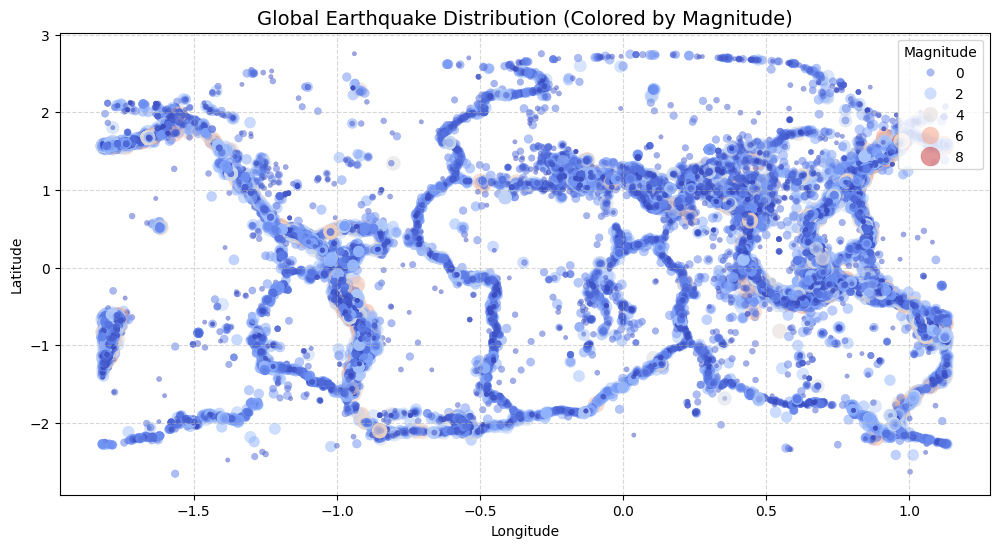

In [13]:
# Q4. Identify Most Active Earthquake Regions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4.1 Load the preprocessed dataset
df_plot = pd.read_csv('D:\\internship\\impactsenseAI-Infosys-Intern-project\\data\\preprocessed_earthquake_data.csv')

# Display first few rows for verification
print(df_plot[['latitude', 'longitude', 'mag']].head())

# 4.2 Remove missing or invalid coordinates
df_plot = df_plot.dropna(subset=['latitude', 'longitude', 'mag'])

# 4.3 Scatter plot — latitude vs longitude, colored and sized by magnitude
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='mag',          # color by magnitude
    size='mag',         # size by magnitude
    data=df_plot,
    palette='coolwarm', # good color gradient
    sizes=(10, 200),    # control point size range
    alpha=0.5,          # transparency for overlapping points
    edgecolor=None
)

# 4.4 Labels and styling
plt.title("Global Earthquake Distribution (Colored by Magnitude)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', title='Magnitude')
plt.show()
